# RouteRight AI: Incident Reassignment Prediction
## Member 4: Data Leakage Validation, Feature Finalization, and Train/Test Split

**Member:** I.A. Samararathna — IT23648036

---
### Purpose
This notebook takes the pre-split dataset produced by Member 3 (`routeright_presplit_dataset.csv`) and:
1. Audits it for data leakage against the assignment's explicit banned-column list
2. Finalizes the leakage-safe feature list as a standalone deliverable
3. Investigates the dataset's temporal distribution to choose an appropriate split strategy
4. Performs a chronological train/test split at the incident level
5. Documents the train/test target-rate drift this split produces
6. Fits all learned preprocessing (missing-value handling, rare-category grouping, one-hot encoding) on the training partition only
7. Produces the final `train.csv` / `test.csv` and a reusable, saved preprocessing pipeline


### 1. Import Libraries and Detect Project Root

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)

# Detect the repository root so the notebook works whether it is
# launched from the project root or the notebooks folder
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "interim" / "routeright_presplit_dataset.csv").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "interim" / "routeright_presplit_dataset.csv").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate data/interim/routeright_presplit_dataset.csv"
    )

os.chdir(PROJECT_ROOT)

DATA_PATH = PROJECT_ROOT / "data" / "interim" / "routeright_presplit_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
DOCS_DIR = PROJECT_ROOT / "docs" / "deliverables_eval1"
FIGURE_DIR = PROJECT_ROOT / "eda_figures"

for d in [PROCESSED_DIR, MODELS_DIR, DOCS_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)


Project root: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor
Dataset path: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\data\interim\routeright_presplit_dataset.csv


### 2. Load the Pre-Split Dataset
Loading the handoff dataset produced by Member 3. This dataset is already leakage-screened at the
column-removal stage and contains engineered temporal features and ordinal encodings, but no
learned transformations (imputation, encoding) have been fitted yet — that is this notebook's job.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["opened_at_dt"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nColumns:")
print(df.columns.tolist())


Dataset loaded successfully.
Shape: 24,918 rows, 16 columns

Columns:
['opened_by', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'assignment_group', 'reassignment_required', 'opened_at_dt', 'opened_hour', 'opened_day_of_week', 'opened_month', 'opened_is_weekend', 'impact_encoded', 'urgency_encoded', 'priority_encoded']


## 3. Feature Availability and Leakage Audit
Member 3 already removed leakage-prone and lifecycle-only columns during preprocessing. Before
proceeding, this notebook independently re-verifies that none of the columns explicitly banned by
the assignment brief survived into the modelling dataset. This is a deliberate audit step, not a
re-derivation of Member 3's work.

In [3]:
# Explicit future-information columns identified as leakage risks in the assignment brief
banned_columns = [
    "reassignment_count", "reopen_count", "resolved_at", "closed_at", "closed_code",
    "resolved_by", "assigned_to", "incident_state", "sys_updated_at", "sys_updated_by",
    "made_sla", "sys_mod_count", "sys_created_at", "sys_created_by", "knowledge",
    "u_priority_confirmation", "notify", "problem_id", "rfc", "vendor", "caused_by",
    "cmdb_ci", "caller_id", "number"
]

leaked_columns_present = [c for c in banned_columns if c in df.columns]

print("Banned/leakage-risk columns present in the handoff dataset:")
print(leaked_columns_present if leaked_columns_present else "None — leakage audit passed.")


Banned/leakage-risk columns present in the handoff dataset:
None — leakage audit passed.


In [4]:
# Define the final feature roles for modelling
final_nominal_features = [
    "opened_by", "contact_type", "location", "category",
    "subcategory", "u_symptom", "assignment_group"
]

final_temporal_features = [
    "opened_hour", "opened_day_of_week", "opened_month", "opened_is_weekend"
]

final_ordinal_features = [
    "impact_encoded", "urgency_encoded", "priority_encoded"
]

final_model_input_features = (
    final_nominal_features + final_temporal_features + final_ordinal_features
)

target_feature = "reassignment_required"
split_reference_feature = "opened_at_dt"

missing_expected = set(final_model_input_features + [target_feature, split_reference_feature]) - set(df.columns)
unexpected_present = set(df.columns) - set(final_model_input_features + [target_feature, split_reference_feature])

print("Total candidate model-input features:", len(final_model_input_features))
print("Expected columns missing from dataset:", missing_expected if missing_expected else "None")
print("Unexpected columns present in dataset:", unexpected_present if unexpected_present else "None")


Total candidate model-input features: 14
Expected columns missing from dataset: None
Unexpected columns present in dataset: None


### 3.1 Finalized Safe Feature List (Member 4 Deliverable)
This table is the formal, signed-off leakage-safe feature list required by the assignment brief for
Member 4's stage. It documents every feature retained for modelling, its role, and why it is
genuinely available at ticket creation.

In [5]:
final_safe_feature_list = pd.DataFrame([
    ["opened_by", "Nominal", "User who opened the incident; available at creation, manageable cardinality (208 levels)"],
    ["contact_type", "Nominal", "Reporting method; available at creation"],
    ["location", "Nominal", "Affected location; available at creation"],
    ["category", "Nominal", "Initial incident classification; available at creation"],
    ["subcategory", "Nominal", "Initial incident classification; available at creation"],
    ["u_symptom", "Nominal", "User-reported symptom; available at creation"],
    ["assignment_group", "Nominal", "Initial routing group; available at creation, verified not to change before this snapshot"],
    ["opened_hour", "Temporal (engineered)", "Deterministically derived from opened_at"],
    ["opened_day_of_week", "Temporal (engineered)", "Deterministically derived from opened_at"],
    ["opened_month", "Temporal (engineered)", "Deterministically derived from opened_at"],
    ["opened_is_weekend", "Temporal (engineered)", "Deterministically derived from opened_at"],
    ["impact_encoded", "Ordinal (engineered)", "Initial incident attribute; deterministic severity mapping"],
    ["urgency_encoded", "Ordinal (engineered)", "Initial incident attribute; deterministic severity mapping"],
    ["priority_encoded", "Ordinal (engineered)", "Initial incident attribute; deterministic severity mapping"],
], columns=["Feature", "Role", "Availability Justification"])

display(final_safe_feature_list)

final_safe_feature_list.to_csv(DOCS_DIR / "final_safe_feature_list.csv", index=False)
print("\nSaved:", DOCS_DIR / "final_safe_feature_list.csv")


,Feature,Role,Availability Justification
0,opened_by,Nominal,User who opened the incident; available at cre...
1,contact_type,Nominal,Reporting method; available at creation
2,location,Nominal,Affected location; available at creation
3,category,Nominal,Initial incident classification; available at ...
4,subcategory,Nominal,Initial incident classification; available at ...
5,u_symptom,Nominal,User-reported symptom; available at creation
6,assignment_group,Nominal,"Initial routing group; available at creation, ..."
7,opened_hour,Temporal (engineered),Deterministically derived from opened_at
8,opened_day_of_week,Temporal (engineered),Deterministically derived from opened_at
9,opened_month,Temporal (engineered),Deterministically derived from opened_at



Saved: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval1\final_safe_feature_list.csv


## 4. Temporal Distribution Check
Before choosing a split strategy, the actual distribution of `opened_at_dt` needs to be understood.
A calendar-based "older vs. newer" cutoff only works if incident volume is reasonably spread across
the covered period.

In [6]:
year_month_counts = df["opened_at_dt"].dt.to_period("M").value_counts().sort_index()
print("Incidents per year-month:")
print(year_month_counts)

concentrated_months = ["2016-02", "2016-03", "2016-04", "2016-05"]
concentrated_count = df["opened_at_dt"].dt.to_period("M").astype(str).isin(concentrated_months).sum()
concentrated_pct = concentrated_count / len(df) * 100

print(f"\nIncidents opened Feb-May 2016: {concentrated_count:,} ({concentrated_pct:.1f}% of all incidents)")
print(f"Incidents opened Jun 2016 onward: {len(df) - concentrated_count:,} ({100 - concentrated_pct:.1f}% of all incidents)")


Incidents per year-month:
opened_at_dt
2016-02     207
2016-03    8995
2016-04    7934
2016-05    7508
2016-06       5
2016-07      14
2016-08      15
2016-09      12
2016-10      16
2016-11      26
2016-12      37
2017-01      94
2017-02      55
Freq: M, Name: count, dtype: int64

Incidents opened Feb-May 2016: 24,644 (98.9% of all incidents)
Incidents opened Jun 2016 onward: 274 (1.1% of all incidents)


**Finding:** Incident volume is extremely concentrated in a 3-4 month window. A calendar-based
cutoff (e.g. "everything after May 2016 is test") would leave the test set with only a few hundred
incidents thinly spread across nine months — too small and unrepresentative to evaluate a model on.

**Decision:** Split chronologically by **row-count percentile** instead of by a fixed calendar date.
Sorting all incidents by `opened_at_dt` and cutting at a fixed percentage of rows keeps the split
strictly time-ordered (no future information leaks into training) while producing a usably sized test set,
because the cutoff falls naturally within the dense period rather than in the sparse tail.

## 5. Chronological Train/Test Split (Row-Count Percentile)

In [7]:
SPLIT_FRACTION = 0.85  # 85% train / 15% test, by row count, in chronological order

df_sorted = df.sort_values("opened_at_dt").reset_index(drop=True)

n = len(df_sorted)
cutoff_idx = int(n * SPLIT_FRACTION)
cutoff_date = df_sorted.loc[cutoff_idx, "opened_at_dt"]

train_df = df_sorted.iloc[:cutoff_idx].copy()
test_df = df_sorted.iloc[cutoff_idx:].copy()

print(f"Split fraction: {SPLIT_FRACTION:.0%} train / {1 - SPLIT_FRACTION:.0%} test")
print(f"Cutoff date: {cutoff_date}")
print(f"\nTrain: {len(train_df):,} rows  ({train_df['opened_at_dt'].min()}  to  {train_df['opened_at_dt'].max()})")
print(f"Test:  {len(test_df):,} rows  ({test_df['opened_at_dt'].min()}  to  {test_df['opened_at_dt'].max()})")


Split fraction: 85% train / 15% test
Cutoff date: 2016-05-16 10:28:00

Train: 21,180 rows  (2016-02-29 01:16:00  to  2016-05-16 10:28:00)
Test:  3,738 rows  (2016-05-16 10:28:00  to  2017-02-16 14:17:00)


### 5.1 Split Integrity Verification
Verifies the split introduces no leakage. Note: the incident identifier (`number`) was already
dropped upstream by Member 3, so incident-level duplication is checked structurally instead — since
each row in this dataset already represents exactly one incident (guaranteed by Member 1's
reconstruction step), and this split is a simple chronological row partition with no joins or
grouping involved, no row can appear in both partitions by construction. Row-count and temporal
ordering are verified explicitly below.

In [8]:
# 1. No temporal overlap: every test timestamp must be >= every train timestamp
no_temporal_overlap = train_df["opened_at_dt"].max() <= test_df["opened_at_dt"].min()

# 2. Row count preserved: every row lands in exactly one partition
row_count_preserved = (len(train_df) + len(test_df)) == len(df_sorted)

# 3. No duplicate index values across partitions (would indicate an accidental row duplication)
no_duplicate_rows_across_split = set(train_df.index).isdisjoint(set(test_df.index))

split_integrity_checks = pd.DataFrame({
    "Check": [
        "No temporal overlap (train max <= test min)",
        "Row count preserved across split",
        "No duplicate rows across train/test"
    ],
    "Passed": [
        no_temporal_overlap,
        row_count_preserved,
        no_duplicate_rows_across_split
    ]
})

display(split_integrity_checks)

assert no_temporal_overlap, "Temporal overlap detected between train and test!"
assert row_count_preserved, "Row count mismatch after split!"
assert no_duplicate_rows_across_split, "Duplicate rows found across train/test split!"
print("\nAll split integrity checks passed.")


,Check,Passed
0,No temporal overlap (train max <= test min),True
1,Row count preserved across split,True
2,No duplicate rows across train/test,True



All split integrity checks passed.


## 6. Target Distribution and Temporal Drift Documentation
Because the split is chronological rather than random, the class balance in train and test is not
guaranteed to match. This needs to be reported explicitly rather than corrected — rebalancing it
would defeat the purpose of a time-aware evaluation.

In [9]:
train_rate = train_df[target_feature].mean() * 100
test_rate = test_df[target_feature].mean() * 100

target_drift_summary = pd.DataFrame({
    "Partition": ["Train", "Test"],
    "Incident_Count": [len(train_df), len(test_df)],
    "Reassignment_Rate_%": [round(train_rate, 2), round(test_rate, 2)]
})

display(target_drift_summary)

print(f"\nObserved drift: {train_rate - test_rate:.2f} percentage points lower reassignment rate in test.")
print("This reflects a genuine change in incident behaviour over time in the source data,")
print("not a split or coding error. It is documented here as a known limitation for model evaluation.")


,Partition,Incident_Count,Reassignment_Rate_%
0,Train,21180,47.12
1,Test,3738,37.13



Observed drift: 9.99 percentage points lower reassignment rate in test.
This reflects a genuine change in incident behaviour over time in the source data,
not a split or coding error. It is documented here as a known limitation for model evaluation.


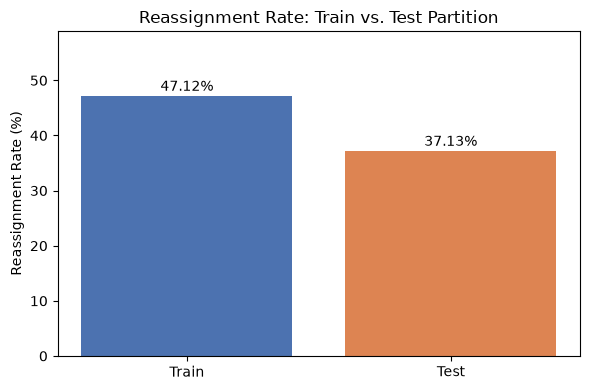

Saved: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\eda_figures\train_test_target_drift.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_drift_summary["Partition"], target_drift_summary["Reassignment_Rate_%"], color=["#4C72B0", "#DD8452"])

ax.set_title("Reassignment Rate: Train vs. Test Partition")
ax.set_ylabel("Reassignment Rate (%)")
ax.set_ylim(0, max(target_drift_summary["Reassignment_Rate_%"]) * 1.25)

for bar, rate in zip(bars, target_drift_summary["Reassignment_Rate_%"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{rate:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "train_test_target_drift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", FIGURE_DIR / "train_test_target_drift.png")


## 7. Preprocessing Pipeline (Fit on Training Data Only)
All learned preprocessing — missing-value handling, rare-category grouping, and one-hot encoding —
is fit exclusively on the training partition and then applied unchanged to the test partition, to
prevent test-set information from influencing the transformation.

**Note on category labels:** this dataset's own anonymization scheme writes category values as
verbose labels that restate the column name — e.g. the `opened_by` column contains values like
`"Opened by  17"`, `location` contains `"Location 143"`, and so on. Left as-is, one-hot encoding
produces stuttering column names like `opened_by_Opened by  17`. A small cleaning step strips this
redundant prefix first, so the final columns read `opened_by_17`, `location_143`, etc. This is purely
cosmetic — it does not change which categories get grouped as rare, nor the resulting feature
dimensionality.

In [11]:
class CategoryLabelCleaner(BaseEstimator, TransformerMixin):
    """Strips column-name-restating prefixes from this dataset's anonymized category labels
    (e.g. 'Opened by  17' -> '17') so one-hot column names don't stutter. Purely cosmetic —
    does not affect category frequencies, rare-category grouping, or feature counts."""

    def __init__(self, prefix_map=None):
        self.prefix_map = prefix_map or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col, prefix_pattern in self.prefix_map.items():
            if col in X.columns:
                # Only touch non-null entries, so real missing values stay as-is
                # (plain NaN, not pandas' nullable NA) for SimpleImputer to handle next.
                not_null = X[col].notna()
                X.loc[not_null, col] = (
                    X.loc[not_null, col].astype(str)
                    .str.replace(prefix_pattern, "", regex=True)
                    .str.strip()
                )
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)

# Only these columns embed a redundant column-name prefix in their raw category labels
label_prefix_map = {
    "opened_by": r"^Opened by\s+",
    "location": r"^Location\s+",
    "category": r"^Category\s+",
    "subcategory": r"^Subcategory\s+",
    "u_symptom": r"^Symptom\s+",
    "assignment_group": r"^Group\s+",
}

print("CategoryLabelCleaner defined.")
print("Columns to clean:", list(label_prefix_map.keys()))
print("Columns left as-is:", [c for c in final_nominal_features if c not in label_prefix_map])


CategoryLabelCleaner defined.
Columns to clean: ['opened_by', 'location', 'category', 'subcategory', 'u_symptom', 'assignment_group']
Columns left as-is: ['contact_type']


In [12]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Groups categories below `threshold` frequency, learned from training data only, into 'Other'."""

    def __init__(self, threshold=0.01, other_label="Other"):
        self.threshold = threshold
        self.other_label = other_label

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.frequent_categories_ = {}
        for col in X.columns:
            freqs = X[col].value_counts(normalize=True, dropna=True)
            self.frequent_categories_[col] = set(freqs[freqs >= self.threshold].index)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            frequent = self.frequent_categories_.get(col, set())
            X[col] = X[col].where(X[col].isin(frequent), self.other_label)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)

print("RareCategoryGrouper defined.")


RareCategoryGrouper defined.


In [13]:
nominal_pipeline = Pipeline(steps=[
    ("clean_labels", CategoryLabelCleaner(prefix_map=label_prefix_map)),
    ("impute_missing", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("group_rare", RareCategoryGrouper(threshold=0.01, other_label="Other")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", nominal_pipeline, final_nominal_features),
        ("passthrough_numeric", "passthrough", final_temporal_features + final_ordinal_features)
    ],
    verbose_feature_names_out=False
)

print("Preprocessing pipeline defined:")
print("  - Nominal features: clean redundant label prefixes -> impute missing -> group rare categories (< 1%, learned from train) -> one-hot encode")
print("  - Temporal + ordinal features: passthrough (already deterministic/numeric)")


Preprocessing pipeline defined:
  - Nominal features: clean redundant label prefixes -> impute missing -> group rare categories (< 1%, learned from train) -> one-hot encode
  - Temporal + ordinal features: passthrough (already deterministic/numeric)


In [14]:
X_train = train_df[final_model_input_features]
X_test = test_df[final_model_input_features]

# Fit on training data only
preprocessor.fit(X_train)

X_train_transformed = np.asarray(preprocessor.transform(X_train))
X_test_transformed = np.asarray(preprocessor.transform(X_test))

feature_names_out = preprocessor.get_feature_names_out()

print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Transformed test shape:  {X_test_transformed.shape}")
print(f"Total output features: {len(feature_names_out)}")
print(f"\nAny missing values remaining in transformed train? {np.isnan(X_train_transformed).any()}")
print(f"Any missing values remaining in transformed test?  {np.isnan(X_test_transformed).any()}")

print("\nSample cleaned one-hot column names:")
print([f for f in feature_names_out if f.startswith(("opened_by_", "location_", "category_"))][:8])


Transformed train shape: (21180, 109)
Transformed test shape:  (3738, 109)
Total output features: 109

Any missing values remaining in transformed train? False
Any missing values remaining in transformed test?  False

Sample cleaned one-hot column names:
['opened_by_108', 'opened_by_131', 'opened_by_17', 'opened_by_180', 'opened_by_221', 'opened_by_239', 'opened_by_24', 'opened_by_301']


## 8. Assemble and Save Final Train/Test Datasets
The split-reference column (`opened_at_dt`) has now done its job and is dropped — it must never be
passed to the model as a predictor.

In [15]:
train_final = pd.DataFrame(X_train_transformed, columns=feature_names_out, index=train_df.index)
train_final[target_feature] = train_df[target_feature].values

test_final = pd.DataFrame(X_test_transformed, columns=feature_names_out, index=test_df.index)
test_final[target_feature] = test_df[target_feature].values

print("Final train shape:", train_final.shape)
print("Final test shape:", test_final.shape)

TRAIN_PATH = PROCESSED_DIR / "train.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"

train_final.to_csv(TRAIN_PATH, index=False)
test_final.to_csv(TEST_PATH, index=False)

print("\nSaved:", TRAIN_PATH)
print("Saved:", TEST_PATH)


Final train shape: (21180, 110)
Final test shape: (3738, 110)

Saved: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\data\processed\train.csv
Saved: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\data\processed\test.csv


## 9. Save the Fitted Preprocessing Pipeline

In [16]:
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.pkl"

joblib.dump(preprocessor, PIPELINE_PATH)
print("Saved fitted preprocessing pipeline to:", PIPELINE_PATH)

# Reload check — confirms the saved pipeline can be loaded and reused independently,
# e.g. by the backend service in Stage 9.
reloaded_preprocessor = joblib.load(PIPELINE_PATH)
sample_check = np.asarray(reloaded_preprocessor.transform(X_test.head(5)))
print("Reload + transform check shape:", sample_check.shape)
print("Pipeline reload verified successfully.")


Saved fitted preprocessing pipeline to: c:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\models\preprocessing_pipeline.pkl
Reload + transform check shape: (5, 109)
Pipeline reload verified successfully.


## 10. Final Validation Summary
A structural checklist confirming the notebook's deliverables are complete and correct. Each check
below tests an actual condition rather than being a placeholder.

In [17]:
validation_results = {
    "Leakage audit passed (no banned columns present)": len(leaked_columns_present) == 0,
    "All expected model-input features present": len(missing_expected) == 0,
    "No unexpected columns in handoff dataset": len(unexpected_present) == 0,
    "Split has no temporal overlap": no_temporal_overlap,
    "Split preserves total row count": row_count_preserved,
    "Split has no duplicate rows across partitions": no_duplicate_rows_across_split,
    "Transformed train has no missing values": not np.isnan(X_train_transformed).any(),
    "Transformed test has no missing values": not np.isnan(X_test_transformed).any(),
    "Target present in train.csv": target_feature in train_final.columns,
    "Target present in test.csv": target_feature in test_final.columns,
    "train.csv saved to data/processed/": TRAIN_PATH.exists(),
    "test.csv saved to data/processed/": TEST_PATH.exists(),
    "Fitted pipeline saved to models/": PIPELINE_PATH.exists(),
    "Fitted pipeline reloads and transforms correctly": sample_check.shape[0] == 5,
}

validation_table = pd.DataFrame(
    validation_results.items(), columns=["Validation Check", "Passed"]
)

display(validation_table)

all_passed = all(validation_results.values())
print(f"\nAll validation checks passed: {all_passed}")


,Validation Check,Passed
0,Leakage audit passed (no banned columns present),True
1,All expected model-input features present,True
2,No unexpected columns in handoff dataset,True
3,Split has no temporal overlap,True
4,Split preserves total row count,True
5,Split has no duplicate rows across partitions,True
6,Transformed train has no missing values,True
7,Transformed test has no missing values,True
8,Target present in train.csv,True
9,Target present in test.csv,True



All validation checks passed: True


## Summary — Member 4 Deliverables

| Item | Description |
|---|---|
| Leakage audit | Verified no banned future-information columns survived into the modelling dataset |
| `final_safe_feature_list.csv` | 14 leakage-safe model-input features, with role and availability justification |
| Split strategy | Chronological, row-count percentile split (85/15) — chosen over a calendar-based cutoff because 98%+ of incidents fall in a 3-month window |
| Train/test | 21,180 train rows (Feb 29 – May 16, 2016) / 3,738 test rows (May 16, 2016 – Feb 16, 2017) |
| Documented limitation | Train reassignment rate 47.1% vs. test 37.1% — genuine temporal drift in the source data, not a split artifact |
| `data/processed/train.csv`, `test.csv` | Final ML-ready datasets, fully encoded, no missing values |
| `models/preprocessing_pipeline.pkl` | Fitted `ColumnTransformer` (imputation + rare-category grouping + one-hot encoding), fit on training data only, verified reloadable |
